# Experimento 1 - Modelo A

N = 100000
m0 = 5, m = 3
Grau minimo observado = 3
Grau maximo observado = 45


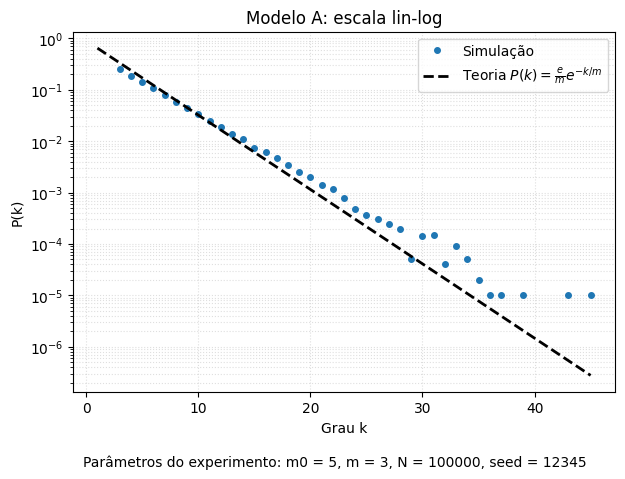

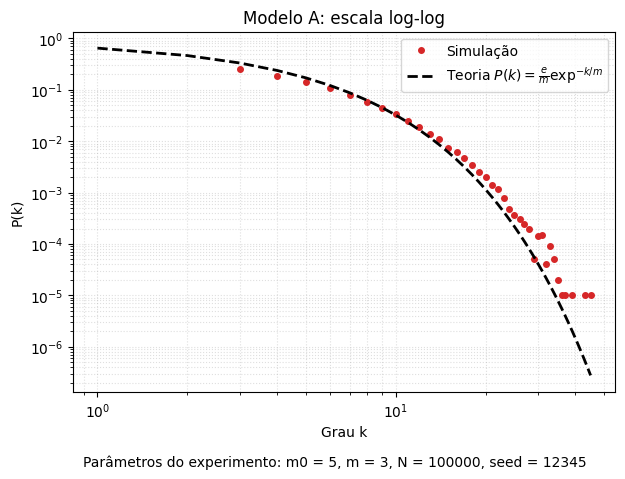

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def simulate_model_a(n_final=100_000, m0=5, m=3, seed=42):
    """Simula o Modelo A: crescimento sem conexão preferencial."""
    if n_final < m0:
        raise ValueError("n_final must be at least m0")
    if m > m0:
        raise ValueError("m must be <= m0")

    rng = np.random.default_rng(seed)
    degrees = np.zeros(n_final, dtype=np.int32)

    # Rede inicial completa K_m0.
    degrees[:m0] = m0 - 1

    # Cada novo nó escolhe m nós existentes de forma uniforme e sem reposição.
    for new_node in range(m0, n_final):
        targets = rng.choice(new_node, size=m, replace=False)
        degrees[new_node] = m
        degrees[targets] += 1

    return degrees


def degree_distribution_probabilities(degrees):
    """Calcula P(k) a partir do vetor de graus."""
    counts = np.bincount(degrees)
    p_k = counts / degrees.size
    ks = np.arange(counts.size)
    return ks, p_k


m0 = 5
m = 3
N = 100_000
seed = 12345

degrees = simulate_model_a(n_final=N, m0=m0, m=m, seed=seed)
ks, p_k = degree_distribution_probabilities(degrees)
p_theory = (np.e / m) * np.exp(-ks / m)

valid = (ks > 0) & (p_k > 0)
valid_theory = ks > 0

caption = f"Parâmetros do experimento: m0 = {m0}, m = {m}, N = {N}, seed = {seed}"

fig1, ax1 = plt.subplots(figsize=(7, 5))
fig1.subplots_adjust(bottom=0.16)
ax1.plot(ks[valid], p_k[valid], "o", ms=4, color="#1f77b4", label="Simulação")
ax1.plot(ks[valid_theory], p_theory[valid_theory], "k--", lw=2, label=r"Teoria $P(k) = \frac{e}{m}e^{-k/m}$")
ax1.set_yscale("log")
ax1.set_xlabel("Grau k")
ax1.set_ylabel("P(k)")
ax1.set_title("Modelo A: escala lin-log")
ax1.grid(True, which="both", ls=":", alpha=0.4)
ax1.legend()
fig1.text(0.5, 0.02, caption, ha="center", va="center", fontsize=10)

fig2, ax2 = plt.subplots(figsize=(7, 5))
fig2.subplots_adjust(bottom=0.16)
ax2.loglog(ks[valid], p_k[valid], "o", ms=4, color="#d62728", label="Simulação")
ax2.loglog(ks[valid_theory], p_theory[valid_theory], "k--", lw=2, label=r"Teoria $P(k) = \frac{e}{m}\text{exp}^{-k/m}$")
ax2.set_xlabel("Grau k")
ax2.set_ylabel("P(k)")
ax2.set_title("Modelo A: escala log-log")
ax2.grid(True, which="both", ls=":", alpha=0.4)
ax2.legend()
fig2.text(0.5, 0.02, caption, ha="center", va="center", fontsize=10)

print(f"N = {N}")
print(f"m0 = {m0}, m = {m}")
print(f"Grau minimo observado = {degrees.min()}")
print(f"Grau maximo observado = {degrees.max()}")
plt.show()

# Experimento 2 - Modelo B

N = 10000
Snapshots capturados: ['T=N', 'T=5N', 'T=40N']
  T=N: k_min=0, k_max=244, <k>=2.00
  T=5N: k_min=0, k_max=600, <k>=10.00
  T=40N: k_min=27, k_max=1747, <k>=80.00


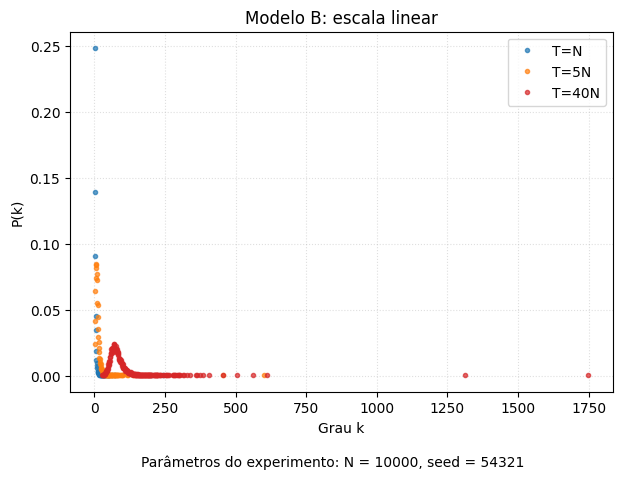

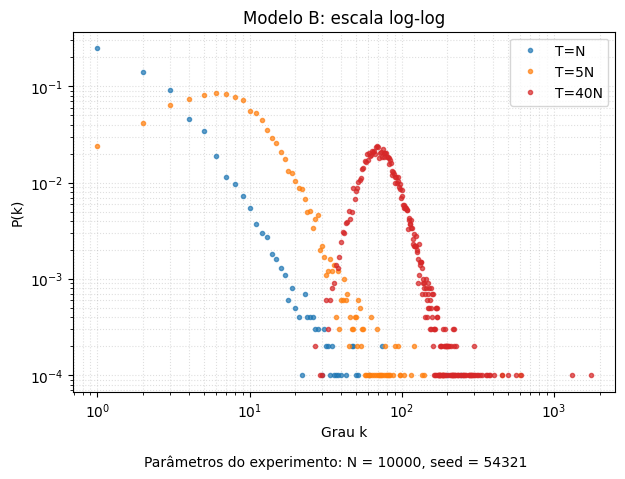

In [22]:
def simulate_model_b(n_nodes=10_000, seed=42):
    """Simula o Modelo B: sistema estático com conexão preferencial.
    
    Começa com N nós isolados.
    A cada passo, adiciona uma aresta entre dois nós.
    A probabilidade de escolher um nó é proporcional ao seu grau.
    Faz snapshots em T=N, T=5N, T=40N e encerra.
    """
    rng = np.random.default_rng(seed)
    degrees = np.zeros(n_nodes, dtype=np.int32)  # Começar com grau 0
    snapshots = {}
    
    for t in range(40 * n_nodes + 1):
        # Escolher o primeiro nó uniformemente aleatoriamente
        i = rng.integers(0, n_nodes)
        
        # Escolher o segundo nó com probabilidade proporcional ao grau suavizado: (k+1)
        probs = degrees / degrees.sum() if degrees.sum() > 0.0 else np.ones(degrees.shape) / len(degrees)
        j = rng.choice(n_nodes, size=1, p=probs)[0]
        
        # Aumentar graus (simulamos uma aresta)
        degrees[i] += 1
        degrees[j] += 1
        
        # Capturar snapshots em épocas específicas
        if t == n_nodes:
            snapshots['T=N'] = degrees.copy()
        elif t == 5 * n_nodes:
            snapshots['T=5N'] = degrees.copy()
        elif t == 40 * n_nodes:
            snapshots['T=40N'] = degrees.copy()
            break
    
    return snapshots


n_nodes_b = 10_000
seed_b = 54321

snapshots = simulate_model_b(n_nodes=n_nodes_b, seed=seed_b)

# Calcular distribuições de probabilidade para cada snapshot
dist_dict = {}
for epoch, deg_array in snapshots.items():
    ks_tmp, p_k_tmp = degree_distribution_probabilities(deg_array)
    dist_dict[epoch] = (ks_tmp, p_k_tmp)

caption_b = f"Parâmetros do experimento: N = {n_nodes_b}, seed = {seed_b}"

# Cores para cada época
colors = {'T=N': '#1f77b4', 'T=5N': '#ff7f0e', 'T=40N': '#d62728'}
labels_b = {'T=N': 'T=N', 'T=5N': 'T=5N', 'T=40N': 'T=40N'}

fig3, ax3 = plt.subplots(figsize=(7, 5))
fig3.subplots_adjust(bottom=0.16)
for epoch in ['T=N', 'T=5N', 'T=40N']:
    if epoch in dist_dict:
        ks_e, p_k_e = dist_dict[epoch]
        valid_e = (ks_e > 0) & (p_k_e > 0)
        ax3.plot(ks_e[valid_e], p_k_e[valid_e], 'o', ms=3, color=colors[epoch], label=labels_b[epoch], alpha=0.7)
ax3.set_xlabel('Grau k')
ax3.set_ylabel('P(k)')
ax3.set_title('Modelo B: escala linear')
ax3.grid(True, which='both', ls=':', alpha=0.4)
ax3.legend()
fig3.text(0.5, 0.02, caption_b, ha='center', va='center', fontsize=10)

fig4, ax4 = plt.subplots(figsize=(7, 5))
fig4.subplots_adjust(bottom=0.16)
for epoch in ['T=N', 'T=5N', 'T=40N']:
    if epoch in dist_dict:
        ks_e, p_k_e = dist_dict[epoch]
        valid_e = (ks_e > 0) & (p_k_e > 0)
        ax4.loglog(ks_e[valid_e], p_k_e[valid_e], 'o', ms=3, color=colors[epoch], label=labels_b[epoch], alpha=0.7)
ax4.set_xlabel('Grau k')
ax4.set_ylabel('P(k)')
ax4.set_title('Modelo B: escala log-log')
ax4.grid(True, which='both', ls=':', alpha=0.4)
ax4.legend()
fig4.text(0.5, 0.02, caption_b, ha='center', va='center', fontsize=10)

print(f"N = {n_nodes_b}")
print(f"Snapshots capturados: {list(snapshots.keys())}")
for epoch, deg_array in snapshots.items():
    print(f"  {epoch}: k_min={deg_array.min()}, k_max={deg_array.max()}, <k>={deg_array.mean():.2f}")
plt.show()

# Experimento 3 - Topologia Scale-Free

Iniciando Experimento 3...
Gamma estimado para o BA: 2.390


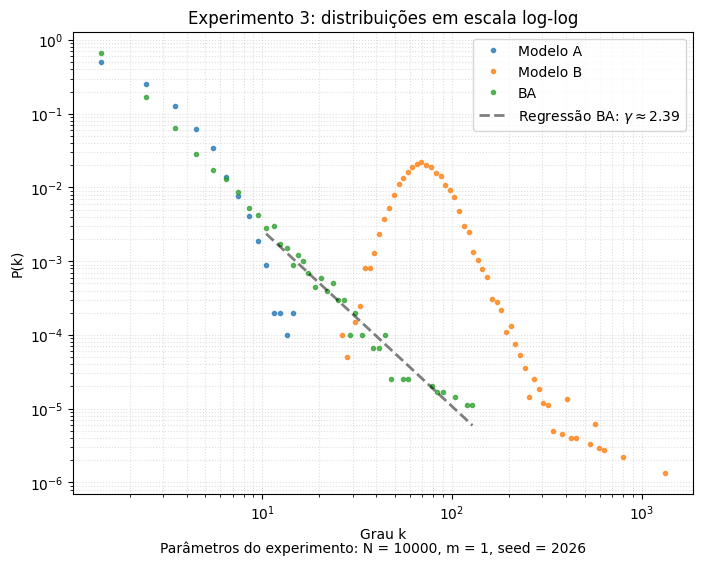

In [31]:
import networkx as nx

def log_binned_distribution(degrees, bins=70):
    counts = np.bincount(degrees)
    ks = np.arange(len(counts))
    positive = ks[counts > 0]
    positive = positive[positive > 0]
    if positive.size == 0:
        return np.array([]), np.array([])

    k_min = positive.min()
    k_max = positive.max()
    edges = np.unique(np.logspace(np.log10(k_min), np.log10(k_max + 1), bins + 1).astype(int))
    if edges.size < 2:
        return np.array([]), np.array([])

    hist, edges = np.histogram(degrees[degrees > 0], bins=edges, density=True)
    centers = np.sqrt(edges[:-1] * edges[1:])
    valid = hist > 0
    return centers[valid], hist[valid]


def fit_power_law_line(x, y, fit_min=10):
    mask = (x >= fit_min) & (y > 0)
    if mask.sum() < 2:
        mask = y > 0
    slope, intercept = np.polyfit(np.log10(x[mask]), np.log10(y[mask]), 1)
    gamma = -slope
    return gamma, slope, intercept


N = 10_000
m = 1
seed = 2026

print('Iniciando Experimento 3...')
degrees_a = simulate_model_a(n_final=N, m0=m, m=m, seed=seed)
snapshots_b = simulate_model_b(n_nodes=N, seed=seed)
degrees_b = snapshots_b['T=40N']
BA = nx.barabasi_albert_graph(n=N, m=m, seed=seed)
degrees_ba = np.array([deg for _, deg in BA.degree()], dtype=np.int64)

x_a3, y_a3 = log_binned_distribution(degrees_a, bins=70)
x_b3, y_b3 = log_binned_distribution(degrees_b, bins=70)
x_ba3, y_ba3 = log_binned_distribution(degrees_ba, bins=70)

gamma_hat, slope_hat, intercept_hat = fit_power_law_line(x_ba3, y_ba3, fit_min=10)
fit_mask = x_ba3 >= 10
if fit_mask.sum() < 2:
    fit_mask = y_ba3 > 0
x_fit = np.linspace(x_ba3[fit_mask].min(), x_ba3[fit_mask].max(), 200)
y_fit = 10 ** (intercept_hat + slope_hat * np.log10(x_fit))

caption3 = f'Parâmetros do experimento: N = {N}, m = {m}, seed = {seed}'

fig5, ax5 = plt.subplots(figsize=(8, 6))
ax5.loglog(x_a3, y_a3, 'o', ms=3, alpha=0.75, label='Modelo A')
ax5.loglog(x_b3, y_b3, 'o', ms=3, alpha=0.75, label='Modelo B')
ax5.loglog(x_ba3, y_ba3, 'o', ms=3, alpha=0.75, label='BA')
ax5.loglog(x_fit, y_fit, 'k--', lw=2, alpha=0.5, label=fr'Regressão BA: $\gamma \approx {gamma_hat:.2f}$')
ax5.set_xlabel('Grau k')
ax5.set_ylabel('P(k)')
ax5.set_title('Experimento 3: distribuições em escala log-log')
ax5.grid(True, which='both', ls=':', alpha=0.4)
ax5.legend()
fig5.text(0.5, 0.02, caption3, ha='center', va='center', fontsize=10)

print(f'Gamma estimado para o BA: {gamma_hat:.3f}')
plt.show()

# Experimento 4 - Distância média

N=100 | BA l=3.1842 | ER l=3.4694
N=1,000 | BA l=4.2190 | ER l=4.9752
N=10,000 | BA l=4.9531 | ER l=6.7237
N=100,000 | BA l=5.8687 | ER l=8.4000


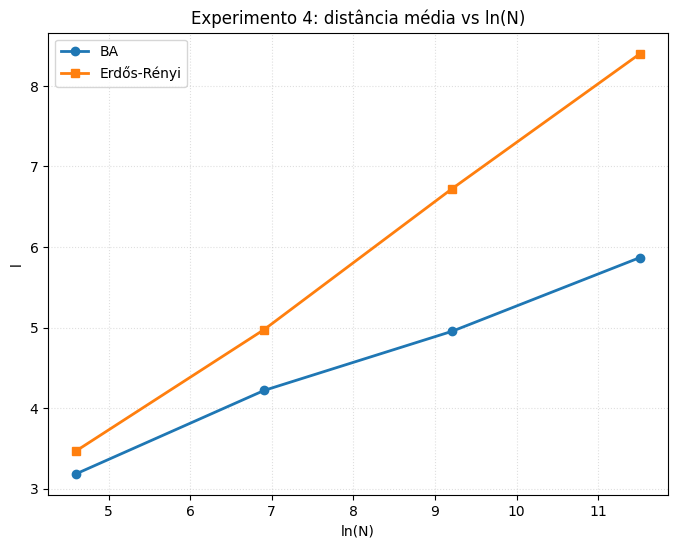

In [32]:
from collections import deque

def average_distance_sampled(graph, sample_size=1000, seed=123):
    rng = np.random.default_rng(seed)
    nodes = np.array(list(graph.nodes()))
    if len(nodes) == 0:
        return np.nan

    sample_size = min(sample_size, len(nodes))
    sample = rng.choice(nodes, size=sample_size, replace=False)

    total_distance = 0
    total_reachable = 0

    for source in sample:
        distances = {source: 0}
        queue = deque([source])
        while queue:
            current = queue.popleft()
            next_distance = distances[current] + 1
            for neighbor in graph.neighbors(current):
                if neighbor not in distances:
                    distances[neighbor] = next_distance
                    queue.append(neighbor)

        if len(distances) > 1:
            total_distance += sum(distances.values())
            total_reachable += len(distances) - 1

    return total_distance / total_reachable if total_reachable > 0 else np.nan


def run_experiment_4(n_values=(10**2, 10**3, 10**4, 10**5), m=2, sample_size=1000, seed=2026):
    ln_n = []
    l_ba = []
    l_er = []

    for i, n in enumerate(n_values):
        graph_seed = seed + i
        ba_graph = nx.barabasi_albert_graph(n=n, m=m, seed=graph_seed)
        er_p = (2 * m) / (n - 1)
        er_graph = nx.erdos_renyi_graph(n=n, p=er_p, seed=graph_seed)

        ln_n.append(np.log(n))
        l_ba.append(average_distance_sampled(ba_graph, sample_size=sample_size, seed=graph_seed))
        l_er.append(average_distance_sampled(er_graph, sample_size=sample_size, seed=graph_seed))

        print(f'N={n:,} | BA l={l_ba[-1]:.4f} | ER l={l_er[-1]:.4f}')

    return np.array(ln_n), np.array(l_ba), np.array(l_er)


ln_n4, l_ba4, l_er4 = run_experiment_4()

fig6, ax6 = plt.subplots(figsize=(8, 6))
ax6.plot(ln_n4, l_ba4, 'o-', lw=2, label='BA')
ax6.plot(ln_n4, l_er4, 's-', lw=2, label='Erdős-Rényi')
ax6.set_xlabel('ln(N)')
ax6.set_ylabel('l')
ax6.set_title('Experimento 4: distância média vs ln(N)')
ax6.grid(True, ls=':', alpha=0.4)
ax6.legend()
plt.show()

# Experimento 5 - Clustering

N=100 | BA C=0.078730 | ER C=0.055492
N=1,000 | BA C=0.025080 | ER C=0.004997
N=10,000 | BA C=0.005140 | ER C=0.000435
N=100,000 | BA C=0.000938 | ER C=0.000023


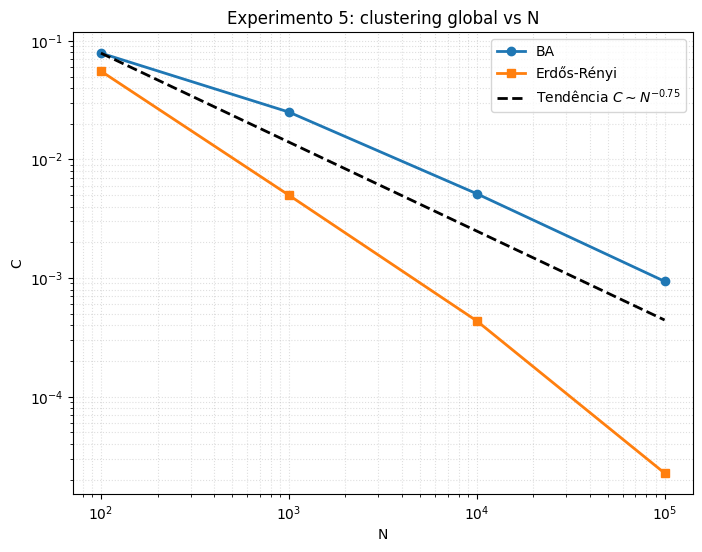

In [34]:
def generate_experiment_4_graphs(n, m=2, seed=2026):
    graph_seed = seed
    ba_graph = nx.barabasi_albert_graph(n=n, m=m, seed=graph_seed)
    er_p = (2 * m) / (n - 1)
    er_graph = nx.erdos_renyi_graph(n=n, p=er_p, seed=graph_seed)
    return ba_graph, er_graph


def clustering_over_sizes(n_values=(10**2, 10**3, 10**4, 10**5), m=2, seed=2026):
    ln_n = []
    c_ba = []
    c_er = []

    for i, n in enumerate(n_values):
        ba_graph, er_graph = generate_experiment_4_graphs(n, m=m, seed=seed + i)
        ln_n.append(np.log(n))
        c_ba.append(nx.average_clustering(ba_graph))
        c_er.append(nx.average_clustering(er_graph))
        print(f'N={n:,} | BA C={c_ba[-1]:.6f} | ER C={c_er[-1]:.6f}')

    return np.array(ln_n), np.array(c_ba), np.array(c_er)


ln_n5, c_ba5, c_er5 = clustering_over_sizes()
trend = ln_n5 * 0 + (ln_n5 / ln_n5)  # placeholder to keep x shape aligned
trend = (np.exp(ln_n5) ** -0.75)
trend = trend / trend[0] * c_ba5[0]

fig7, ax7 = plt.subplots(figsize=(8, 6))
ax7.loglog(np.exp(ln_n5), c_ba5, 'o-', lw=2, label='BA')
ax7.loglog(np.exp(ln_n5), c_er5, 's-', lw=2, label='Erdős-Rényi')
ax7.loglog(np.exp(ln_n5), trend, 'k--', lw=2, label=r'Tendência $C \sim N^{-0.75}$')
ax7.set_xlabel('N')
ax7.set_ylabel('C')
ax7.set_title('Experimento 5: clustering global vs N')
ax7.grid(True, which='both', ls=':', alpha=0.4)
ax7.legend()
plt.show()

# Experimento 6 - Correlação de graus

N = 10,000, m = 3, ensemble = 100
BA assortativity r = -0.0379 ± 0.0039
ER assortativity r = -0.0004 ± 0.0061


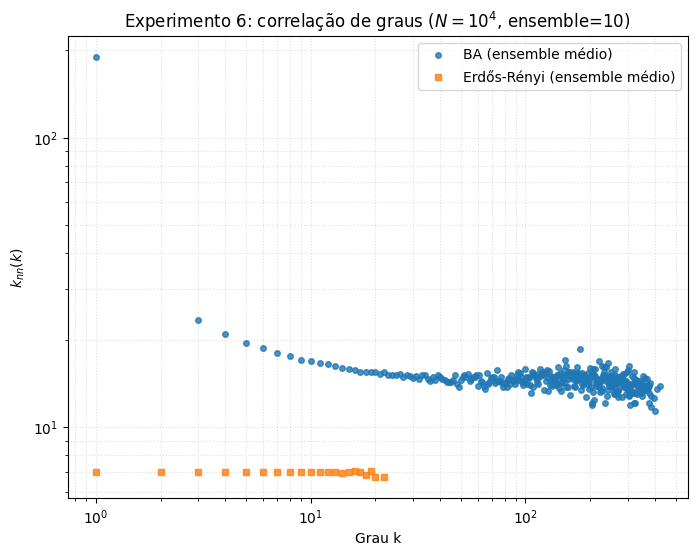

In [ ]:
import networkx as nx

def knn_by_degree(graph):
    avg_neighbor_degree = nx.average_neighbor_degree(graph)
    degree_groups = {}

    for node, degree in graph.degree():
        if degree == 0:
            continue
        degree_groups.setdefault(degree, []).append(avg_neighbor_degree[node])

    ks = np.array(sorted(degree_groups.keys()), dtype=float)
    knn = np.array([np.mean(degree_groups[k]) for k in ks], dtype=float)
    valid = knn > 0
    return ks[valid], knn[valid]


def average_knn_ensemble(graph_factory, ensemble_size=10, seed=2026):
    knn_sums = {}
    knn_counts = {}
    assortativity = []

    for i in range(ensemble_size):
        graph = graph_factory(seed + i)
        assortativity.append(nx.degree_assortativity_coefficient(graph))
        ks, knn = knn_by_degree(graph)
        for degree, value in zip(ks.astype(int), knn):
            knn_sums[degree] = knn_sums.get(degree, 0.0) + float(value)
            knn_counts[degree] = knn_counts.get(degree, 0) + 1

    ks_sorted = np.array(sorted(knn_sums.keys()), dtype=float)
    knn_mean = np.array([knn_sums[k] / knn_counts[k] for k in ks_sorted], dtype=float)
    return ks_sorted, knn_mean, np.array(assortativity, dtype=float)


N6 = 10_000
m6 = 3
ensemble6 = 100
seed6 = 2026

ba_factory = lambda s: nx.barabasi_albert_graph(n=N6, m=m6, seed=s)
er_p6 = (2 * m6) / (N6 - 1)
er_factory = lambda s: nx.erdos_renyi_graph(n=N6, p=er_p6, seed=s)

k_ba6, knn_ba6, r_ba6 = average_knn_ensemble(ba_factory, ensemble_size=ensemble6, seed=seed6)
k_er6, knn_er6, r_er6 = average_knn_ensemble(er_factory, ensemble_size=ensemble6, seed=seed6)

print(f'N = {N6:,}, m = {m6}, ensemble = {ensemble6}')
print(f'BA assortativity r = {r_ba6.mean():.4f} ± {r_ba6.std(ddof=1):.4f}')
print(f'ER assortativity r = {r_er6.mean():.4f} ± {r_er6.std(ddof=1):.4f}')

fig8, ax8 = plt.subplots(figsize=(8, 6))
ax8.loglog(k_ba6, knn_ba6, 'o', ms=4, alpha=0.8, label='BA (ensemble médio)')
ax8.loglog(k_er6, knn_er6, 's', ms=4, alpha=0.8, label='Erdős-Rényi (ensemble médio)')
ax8.set_xlabel('Grau k')
ax8.set_ylabel(r'$k_{nn}(k)$')
ax8.set_title(r'Experimento 6: correlação de graus ($N=10^4$, ensemble=100)')
ax8.grid(True, which='both', ls=':', alpha=0.4)
ax8.legend()
plt.show()